# Boids Flockers

An implementation of Craig Reynolds's Boids flocker model. Agents (simulated birds) try to fly towards the average position of their neighbors and in the same direction as them, while maintaining a minimum distance. This produces flocking behavior.

This model tests Mesa's continuous space feature, and uses numpy arrays to represent vectors.

### Set Up

In [1]:
!pip install --quiet mesa[rec]

ERROR: Operation cancelled by user


### Import Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import mesa

ModuleNotFoundError: No module named 'mesa'

## Agent

Each Boid agent follows three simple local rules:
- **Cohesion**: steer toward the average position of neighbours
- **Separation**: avoid getting too close to any neighbour
- **Alignment**: steer toward the average heading of neighbours

In [ ]:
from mesa.experimental.continuous_space import ContinuousSpaceAgent


class Boid(ContinuousSpaceAgent):
    """A Boid-style flocker agent."""

    def __init__(
        self,
        model,
        space,
        position=(0, 0),
        speed=1,
        direction=(1, 1),
        vision=1,
        separation=1,
        cohere=0.03,
        separate=0.015,
        match=0.05,
    ):
        super().__init__(space, model)
        self.position = np.array(position, dtype=float)
        self.speed = speed
        self.direction = np.array(direction, dtype=float)
        self.vision = vision
        self.separation = separation
        self.cohere_factor = cohere
        self.separate_factor = separate
        self.match_factor = match
        self.neighbors = []
        self.angle = 0.0

    def step(self):
        """Get the Boid's neighbors, compute the new vector, and move accordingly."""
        neighbors, distances = self.get_neighbors_in_radius(radius=self.vision)
        self.neighbors = [n for n in neighbors if n is not self]

        if not self.neighbors:
            self.position += self.direction * self.speed
            return

        delta = self.space.calculate_difference_vector(self.position, agents=self.neighbors)
        distances_nb = distances[1:] if len(distances) > 1 else distances  # skip self

        cohere_vector = delta.sum(axis=0) * self.cohere_factor
        norms = np.linalg.norm(delta, axis=1)
        separation_vector = -1 * delta[norms < self.separation].sum(axis=0) * self.separate_factor
        match_vector = (
            np.asarray([n.direction for n in self.neighbors]).sum(axis=0) * self.match_factor
        )

        self.direction += (cohere_vector + separation_vector + match_vector) / len(self.neighbors)

        norm = np.linalg.norm(self.direction)
        if norm > 0:
            self.direction /= norm

        self.position += self.direction * self.speed
        self.angle = np.degrees(np.arctan2(self.direction[1], self.direction[0]))

## Model

In [ ]:
from mesa import Model
from mesa.experimental.continuous_space import ContinuousSpace


class BoidFlockers(Model):
    """Flocker model class. Handles agent creation, placement and scheduling."""

    def __init__(
        self,
        population_size=100,
        width=100,
        height=100,
        speed=1,
        vision=10,
        separation=2,
        cohere=0.03,
        separate=0.015,
        match=0.05,
        seed=None,
    ):
        super().__init__(seed=seed)

        self.space = ContinuousSpace(
            [[0, width], [0, height]],
            torus=True,
            random=self.random,
            n_agents=population_size,
        )

        positions = self.rng.random(size=(population_size, 2)) * self.space.size
        directions = self.rng.uniform(-1, 1, size=(population_size, 2))

        Boid.create_agents(
            self,
            population_size,
            self.space,
            position=positions,
            direction=directions,
            cohere=cohere,
            separate=separate,
            match=match,
            speed=speed,
            vision=vision,
            separation=separation,
        )

        self.average_heading = None
        self.update_average_heading()

    def update_average_heading(self):
        if not self.agents:
            self.average_heading = 0
            return
        headings = np.array([agent.direction for agent in self.agents])
        mean_heading = np.mean(headings, axis=0)
        self.average_heading = np.arctan2(mean_heading[1], mean_heading[0])

    def step(self):
        self.agents.shuffle_do("step")
        self.update_average_heading()

## Visualisation — Matplotlib Animation

> **Note:** Mesa's built-in `SolaraViz` requires a running web server and does **not** work in Colab.
> We replace it with a standard `matplotlib` animation — fully self-contained and Colab-friendly.

In [ ]:
N_BOIDS = 80; WIDTH = 100; HEIGHT = 100; SPEED = 2; VISION = 10; SEPARATION = 2; N_STEPS = 150

model = BoidFlockers(
    population_size=N_BOIDS, width=WIDTH, height=HEIGHT,
    speed=SPEED, vision=VISION, separation=SEPARATION, seed=42,
)

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor("#111111")

def update(frame):
    if frame > 0:
        model.step()
    ax.clear()
    ax.set_xlim(0, WIDTH); ax.set_ylim(0, HEIGHT)
    ax.set_facecolor("#111111"); ax.set_xticks([]); ax.set_yticks([])

    agents   = list(model.agents)
    pos      = np.array([a.position  for a in agents])
    flocking = np.array([len(a.neighbors) >= 2 for a in agents])

    for mask, color in [(~flocking, "#E05252"), (flocking, "#52C07A")]:
        pts = pos[mask]
        if len(pts):
            ax.scatter(pts[:, 0], pts[:, 1], s=20, c=color, zorder=2)

    ax.set_title(f"Step {frame:3d}  |  {100*flocking.mean():.0f}% flocking",
                 color="white", fontsize=11)

ani = animation.FuncAnimation(fig, update, frames=N_STEPS, interval=80)
plt.tight_layout()
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## Order Parameter — Measuring Collective Motion

In physics, the **Vicsek order parameter** $\phi = |\langle \hat{v}_i \rangle|$ measures how aligned the flock is:
- $\phi \approx 0$ → disordered (random directions)
- $\phi \approx 1$ → fully aligned (perfect flock)

This is directly analogous to the **magnetisation** in the Ising model.

/usr/local/lib/python3.12/dist-packages/mesa/mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


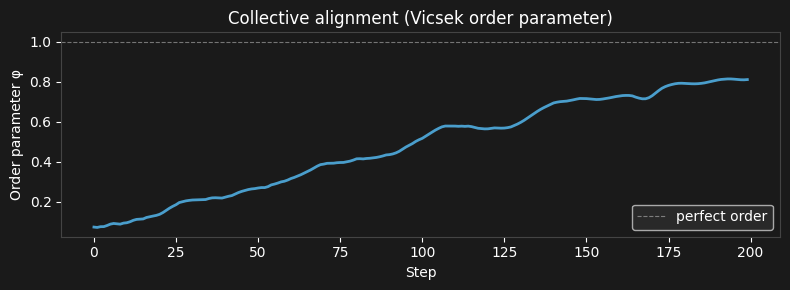

In [ ]:
# Run a fresh simulation and track the order parameter over time
model2 = BoidFlockers(
    population_size=150, width=100, height=100,
    speed=2, vision=10, separation=2, seed=0
)

order_param = []
for _ in range(200):
    model2.step()
    dirs = np.array([a.direction for a in model2.agents])
    mean_v = np.mean(dirs, axis=0)
    order_param.append(np.linalg.norm(mean_v))

fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.plot(order_param, color="#4A9ECC", lw=2)
ax2.axhline(1.0, color="white", lw=0.8, ls="--", alpha=0.4, label="perfect order")
ax2.set_xlabel("Step", color="white")
ax2.set_ylabel("Order parameter φ", color="white")
ax2.set_title("Collective alignment (Vicsek order parameter)", color="white")
ax2.set_facecolor("#1A1A1A")
fig2.patch.set_facecolor("#1A1A1A")
ax2.tick_params(colors="white")
ax2.spines[:].set_color("#444444")
ax2.legend(facecolor="#2D2D2D", labelcolor="white")
plt.tight_layout()
plt.show()